# EDA on Cars Data Set — Practice Notebook

We will explore the **Cars** data set and perform Exploratory Data Analysis (EDA).

**Topics covered:**
- Basic data exploration
- Removing duplicates
- Outlier treatment
- Missing value treatment
- Univariate analysis
- Bivariate analysis
- Normalization and Scaling (numerical variables)
- Encoding (categorical variables)

**Instructions:** Each section below tells you *what to do*. Write your own code in the empty cell that follows each instruction. Do not look at the solution notebook until you've tried it yourself!

## Step 1: Import Libraries

- Import `pandas` as `pd`
- Import `numpy` as `np`
- Import `matplotlib.pyplot` as `plt`
- Import `seaborn` as `sns`

In [43]:
# TODO: write your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Data Set

- Read the file `Cars.xlsx` into a DataFrame called `cr` using `pd.read_excel()`

In [44]:
# TODO: write your code here

cr=pd.read_excel("Cars.xlsx")


## Step 3: Clean Column Names

- Replace spaces in column names with underscores
- Convert column names to Title Case (e.g. `MARITAL STATUS` -> `Marital_Status`)

In [45]:
# TODO: write your code here
cr.columns=cr.columns.str.replace(" ","_")


## Step 4: Basic Data Exploration

Check the following:
- `head()` — first 5 rows
- `shape` — number of rows and columns
- `info()` — column data types and non-null counts
- `describe()` — summary statistics of numerical columns

In [46]:
# TODO: write your code here
cr.head(5)

,INDEX,INCOME,MARITAL_STATUS,SEX,EDUCATION,JOB,TRAVEL_TIME,USE,MILES_CLOCKED,CAR_TYPE,CAR_AGE,CITY,POSTAL_CODE
0,1,125301.24250,No,F,Bachelors,Blue Collar,45.703013,Commercial,17430.0,Sports Car,7.0,Texas,42420.0
1,2,50815.44531,No,M,High School,NaN,20.591628,Private,18930.0,Minivan,1.0,Texas,42420.0
2,3,62977.82416,NaN,F,Bachelors,Clerical,33.639949,Private,NaN,SUV,1.0,Texas,42420.0
3,4,77099.96624,No,F,NaN,Lawyer,15.415676,NaN,18300.0,Sports Car,11.0,Texas,42420.0
4,5,130794.57420,No,M,High School,NaN,NaN,Commercial,28340.0,Panel Truck,10.0,Texas,42420.0


In [47]:
cr.shape

(303, 13)

In [48]:
cr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   INDEX           303 non-null    int64  
 1   INCOME          260 non-null    float64
 2   MARITAL_STATUS  275 non-null    object 
 3   SEX             297 non-null    object 
 4   EDUCATION       259 non-null    object 
 5   JOB             257 non-null    object 
 6   TRAVEL_TIME     262 non-null    float64
 7   USE             250 non-null    object 
 8   MILES_CLOCKED   278 non-null    float64
 9   CAR_TYPE        293 non-null    object 
 10  CAR_AGE         283 non-null    float64
 11  CITY            297 non-null    object 
 12  POSTAL_CODE     300 non-null    float64
dtypes: float64(5), int64(1), object(7)
memory usage: 30.9+ KB


In [49]:
cr.describe()

,INDEX,INCOME,TRAVEL_TIME,MILES_CLOCKED,CAR_AGE,POSTAL_CODE
count,303.000000,260.000000,262.000000,278.000000,283.000000,300.000000
mean,139.640264,50025.162170,34.282098,13591.978417,6.265018,50712.196667
std,85.178422,41186.807914,14.910178,7167.328655,5.111218,24141.029290
min,1.000000,0.000000,5.000000,1500.000000,1.000000,11435.000000
25%,62.500000,20452.885023,24.449874,7900.000000,1.000000,42420.000000
50%,138.000000,44571.590870,33.564757,12065.000000,6.000000,47150.000000
75%,213.500000,66485.761387,43.907339,18240.000000,10.000000,61701.000000
max,289.000000,204667.589700,83.617643,38000.000000,20.000000,90049.000000


## Step 5: Check for Duplicate Records

- Count duplicate rows using `duplicated().sum()`
- Drop duplicate rows in place using `drop_duplicates()`
- Confirm no duplicates remain

In [50]:
# TODO: write your code here
cr.duplicated().sum()

np.int64(14)

In [51]:
cr.drop_duplicates(inplace=True)


In [52]:
cr.shape

(289, 13)

## Step 6: Drop Irrelevant Columns

- The `Index` column is just a row identifier and carries no information. Drop it (`axis=1`, `inplace=True`).

In [53]:
# TODO: write your code here
cr.drop('INDEX', axis=1, inplace=True)



In [55]:
cr.head(5)

,INCOME,MARITAL_STATUS,SEX,EDUCATION,JOB,TRAVEL_TIME,USE,MILES_CLOCKED,CAR_TYPE,CAR_AGE,CITY,POSTAL_CODE
0,125301.24250,No,F,Bachelors,Blue Collar,45.703013,Commercial,17430.0,Sports Car,7.0,Texas,42420.0
1,50815.44531,No,M,High School,NaN,20.591628,Private,18930.0,Minivan,1.0,Texas,42420.0
2,62977.82416,NaN,F,Bachelors,Clerical,33.639949,Private,NaN,SUV,1.0,Texas,42420.0
3,77099.96624,No,F,NaN,Lawyer,15.415676,NaN,18300.0,Sports Car,11.0,Texas,42420.0
4,130794.57420,No,M,High School,NaN,NaN,Commercial,28340.0,Panel Truck,10.0,Texas,42420.0


## Step 7: Separate Categorical and Continuous Columns

- Convert `Postal_Code` to the `category` dtype (it's really a label, not a number)
- Build two lists: `cat` for categorical (text) columns, `con` for continuous (numerical) columns
- Loop through `cr` columns and sort them into `cat` / `con` accordingly (hint: use `pd.api.types.is_numeric_dtype()`)

In [56]:
# TODO: write your code here
cr["POSTAL_CODE"]=cr["POSTAL_CODE"].astype("category")

In [57]:
cat=cr.select_dtypes(include=['object','category','bool']).columns.to_list()

con=cr.select_dtypes(include=['number']).columns.to_list()

In [58]:
print(cat)

['MARITAL_STATUS', 'SEX', 'EDUCATION', 'JOB', 'USE', 'CAR_TYPE', 'CITY', 'POSTAL_CODE']


In [59]:
print(con)

['INCOME', 'TRAVEL_TIME', 'MILES_CLOCKED', 'CAR_AGE']


## Step 8: Check for Missing Values

- Use `isnull().sum()` to see how many missing values each column has

In [60]:
# TODO: write your code here
cr.isnull().sum()

INCOME            43
MARITAL_STATUS    28
SEX                6
EDUCATION         44
JOB               46
TRAVEL_TIME       41
USE               53
MILES_CLOCKED     25
CAR_TYPE          10
CAR_AGE           20
CITY               6
POSTAL_CODE        3
dtype: int64

## Step 9: Visualize Outliers (Before Treatment)

- Plot a boxplot of all continuous columns using `sns.boxplot(data=cr[con])` to visually spot outliers

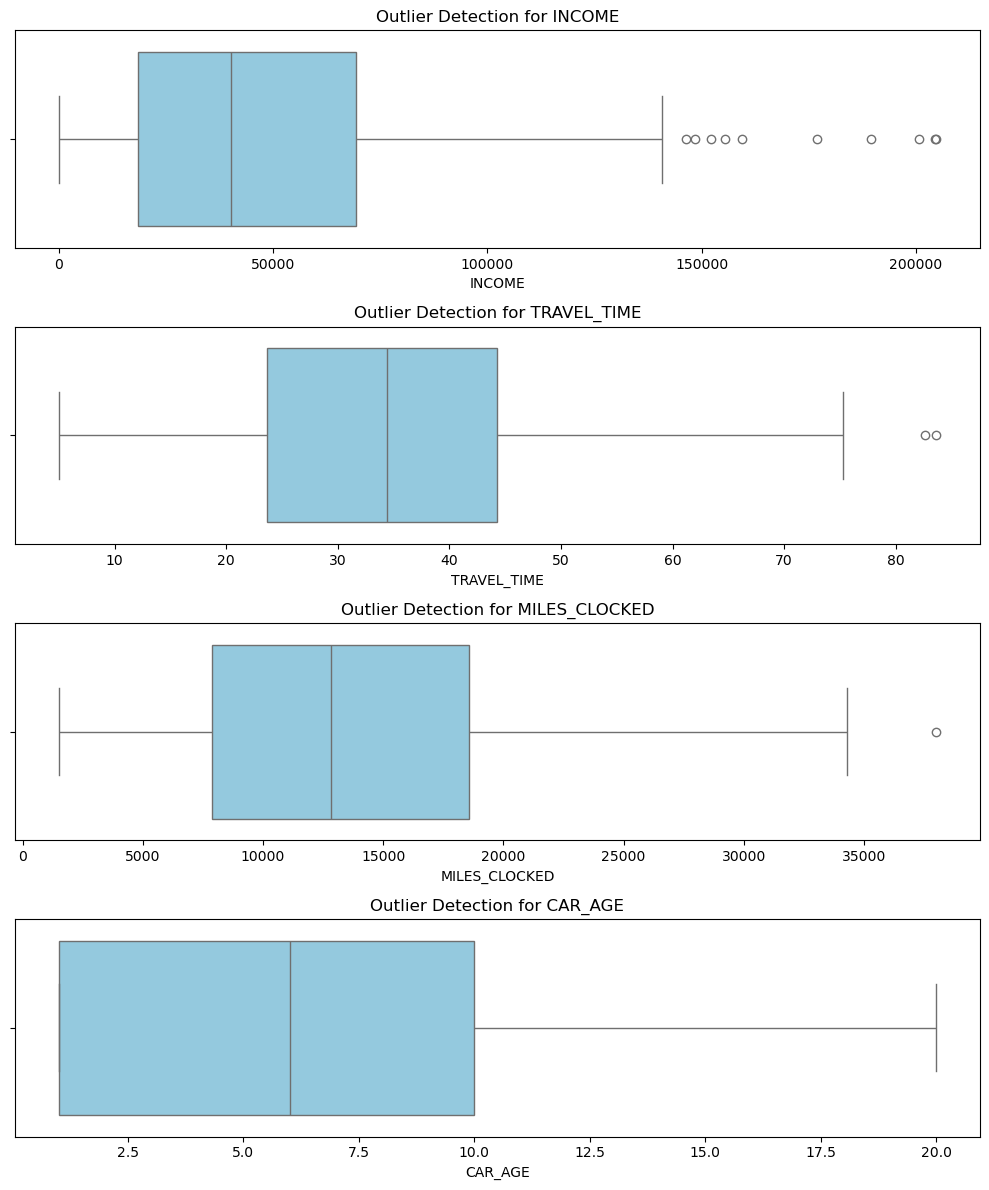

In [61]:
# TODO: write your code here
plt.figure(figsize=(10, 3 * len(con)))


for i, col in enumerate(con, 1):
    plt.subplot(len(con), 1, i)
    sns.boxplot(x=cr[col], color='skyblue')
    plt.title(f'Outlier Detection for {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

## Step 10: Treat Outliers (IQR Method)

For every continuous column:
- Compute Q1 (25th percentile) and Q3 (75th percentile)
- Compute `IQR = Q3 - Q1`
- Compute `upper = Q3 + 1.5*IQR` and `lower = Q1 - 1.5*IQR`
- **Cap** values above `upper` to `upper`, and **floor** values below `lower` to `lower` (use `np.where`)
- Re-plot the boxplot to confirm outliers are treated

In [62]:
# TODO: write your code here

for col in con:
   
    q1 = cr[col].quantile(0.25)
    q3 = cr[col].quantile(0.75)
    qr = q3 - q1
    
    ll = q1 - 1.5 * qr
    ul = q3 + 1.5 * qr
    
    
    cr[col] = np.where(cr[col] < ll, ll, cr[col])
    
   
    cr[col] = np.where(cr[col] > ul, ul, cr[col])





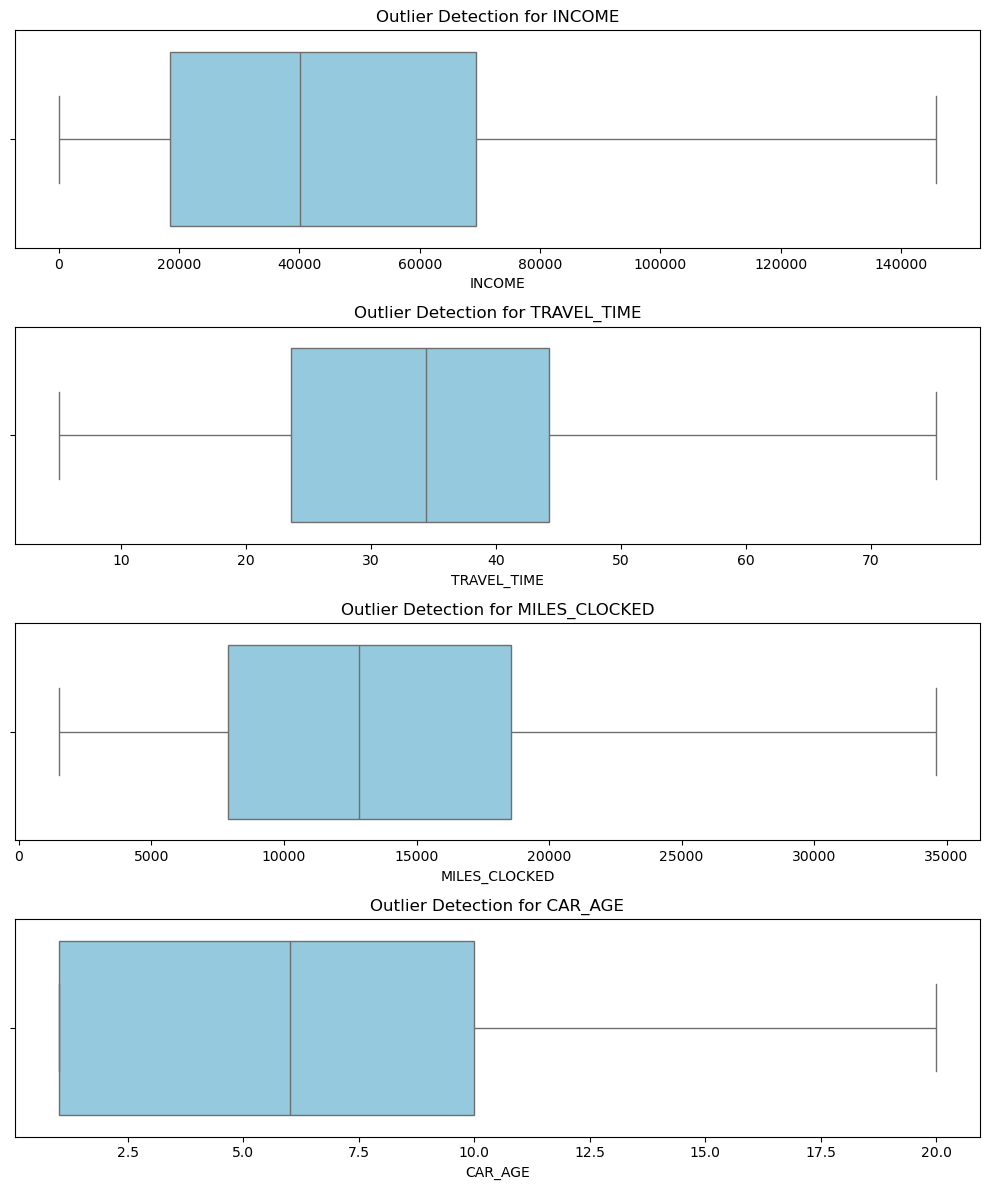

In [63]:
plt.figure(figsize=(10, 3 * len(con)))


for i, col in enumerate(con, 1):
    plt.subplot(len(con), 1, i)
    sns.boxplot(x=cr[col], color='skyblue')
    plt.title(f'Outlier Detection for {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

## Step 11: Impute Missing Values — Continuous Columns

- For each continuous column, replace missing (`NaN`) values with that column's **median**

*(Reminder: Continuous variables -> use Median. Categorical variables -> use Mode.)*

In [68]:
# TODO: write your code here

for col in con:
    median_value = cr[col].mean()
    cr[col] = cr[col].fillna(median_value)




## Step 12: Impute Missing Values — Categorical Columns

- For each categorical column, replace missing values with that column's **mode** (most frequent value)

In [65]:
# TODO: write your code here

for col in cat:
    
    mode_value = cr[col].mode()[0]
    cr[col] = cr[col].fillna(mode_value)



## Step 13: Confirm No Missing Values Remain

- Run `isnull().sum()` on the full DataFrame to confirm 0 missing values everywhere

In [69]:
# TODO: write your code here
cr.isnull().sum()

INCOME            0
MARITAL_STATUS    0
SEX               0
EDUCATION         0
JOB               0
TRAVEL_TIME       0
USE               0
MILES_CLOCKED     0
CAR_TYPE          0
CAR_AGE           0
CITY              0
POSTAL_CODE       0
dtype: int64

## Step 14: Univariate Analysis

- Plot a boxplot of `Income` to check its distribution and skewness
- Plot a countplot of `Education` split by `Sex` (use `hue='Sex'`) to compare education levels between males and females

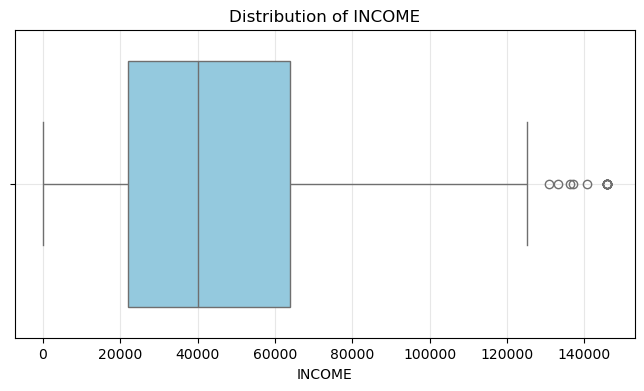

In [70]:
# TODO: write your code here
plt.figure(figsize=(8, 4))
sns.boxplot(x="INCOME", data=cr, color="skyblue")
plt.title("Distribution of INCOME")
plt.grid(alpha=0.3)
plt.show()

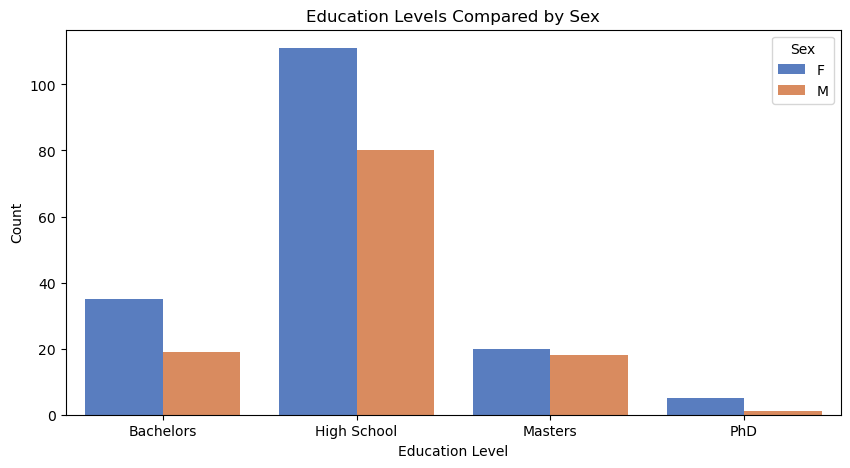

In [71]:
plt.figure(figsize=(10, 5))
sns.countplot(data=cr, x='EDUCATION', hue='SEX', palette='muted')
plt.title('Education Levels Compared by Sex')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Sex')
plt.show()

## Step 15: Bivariate Analysis — Pairplot

- Use `sns.pairplot()` on the continuous columns (`cr[con]`) to see pairwise relationships

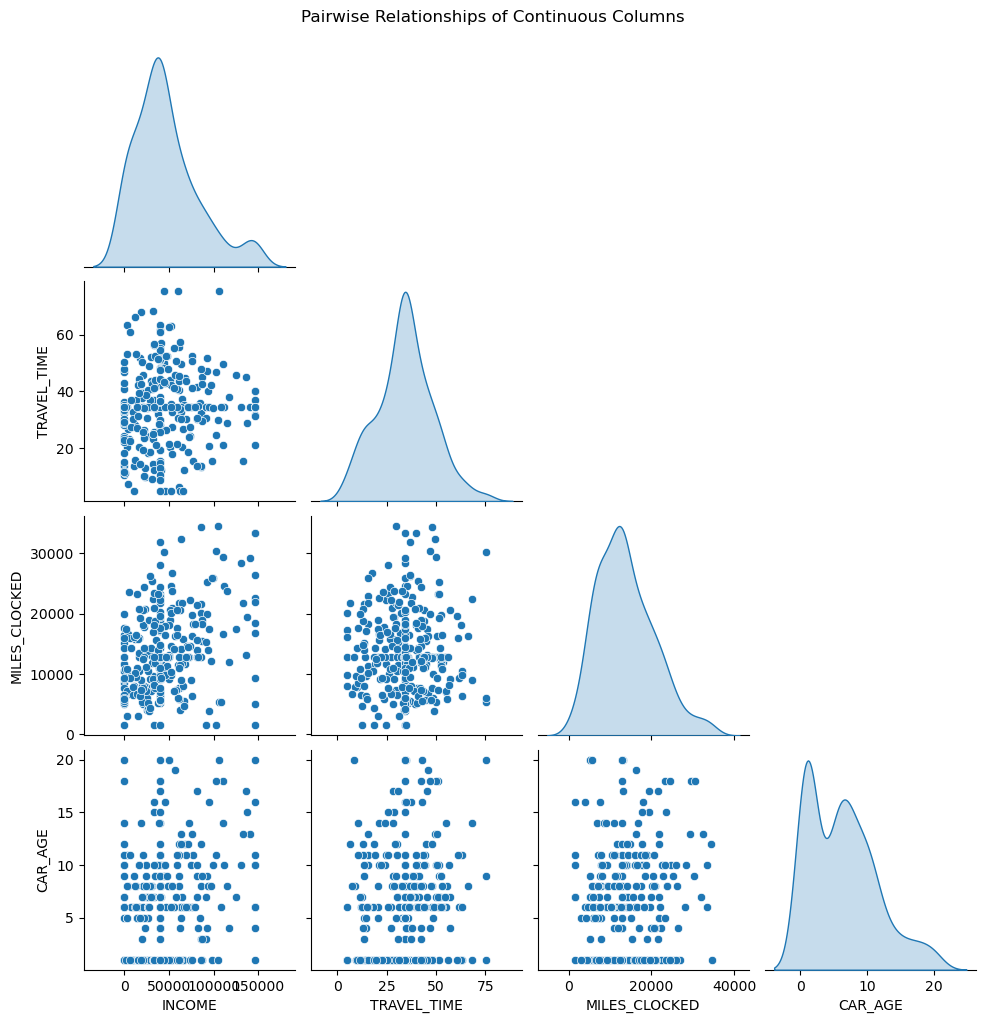

In [72]:
# TODO: write your code here
sns.pairplot(cr[con], diag_kind='kde', corner=True)
plt.suptitle('Pairwise Relationships of Continuous Columns', y=1.02)
plt.show()

## Step 16: Bivariate Analysis — Correlation Heatmap

- Compute the correlation matrix of the continuous columns with `.corr()`
- Visualize it with `sns.heatmap()` (use `annot=True` to show correlation values)

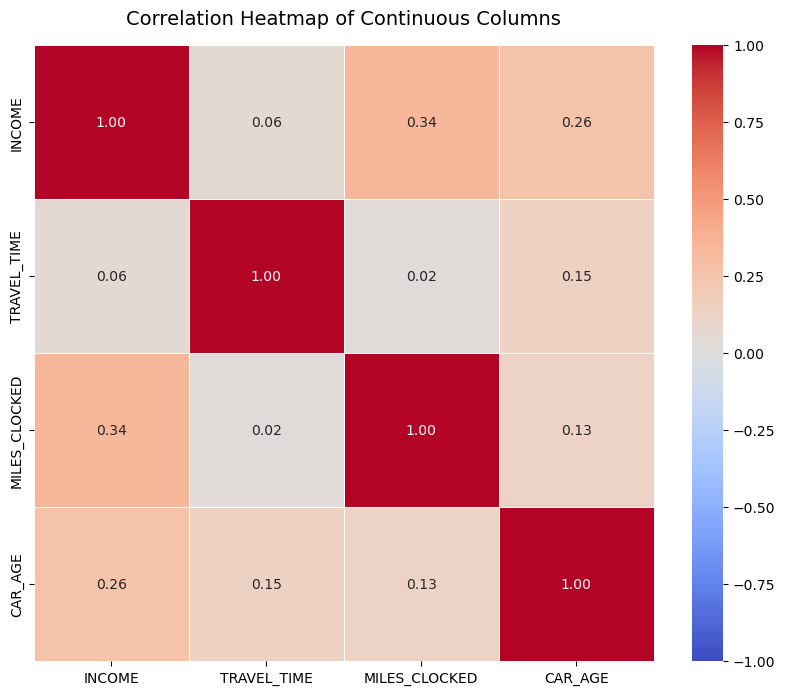

In [73]:
# TODO: write your code here
corr_matrix = cr[con].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Continuous Columns', fontsize=14, pad=15)
plt.show()

## Step 17: Normalization and Scaling

- Import `StandardScaler` from `sklearn.preprocessing`
- Fit and transform the continuous columns (`cr[con]`) using `StandardScaler`
- Store the scaled result in a new DataFrame `cr_std` with the same column names as `con`

In [74]:
# TODO: write your code here

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


scaled_data = scaler.fit_transform(cr[con])

cr_std = pd.DataFrame(scaled_data, columns=con, index=cr.index)

print(cr_std.head())


     INCOME  TRAVEL_TIME  MILES_CLOCKED   CAR_AGE
0  2.186892     0.813273       0.529946  0.137267
1  0.108850    -0.981463       0.748411 -1.052842
2  0.448162    -0.048886      -0.137830 -1.052842
3  0.842148    -1.351394       0.656656  0.930674
4  2.340148     0.007325       2.118917  0.732322


## Step 18: Encoding Categorical Variables

- Convert each categorical column to the `category` dtype
- Use `pd.get_dummies()` on the categorical columns with `drop_first=True` to one-hot encode them
- Store the result in `dummies`

In [75]:
# TODO: write your code here

for col in cat:
    cr[col] = cr[col].astype('category')
dummies = pd.get_dummies(cr[cat], drop_first=True)

print(dummies.head())

   MARITAL_STATUS_Yes  SEX_M  EDUCATION_High School  EDUCATION_Masters  \
0               False  False                  False              False   
1               False   True                   True              False   
2               False  False                  False              False   
3               False  False                   True              False   
4               False   True                   True              False   

   EDUCATION_PhD  JOB_Clerical  JOB_Doctor  JOB_Home Maker  JOB_Lawyer  \
0          False         False       False           False       False   
1          False         False       False           False       False   
2          False          True       False           False       False   
3          False         False       False           False        True   
4          False         False       False           False       False   

   JOB_Manager  ...  POSTAL_CODE_12180.0  POSTAL_CODE_42420.0  \
0        False  ...                False     

## Step 19: Combine Scaled + Encoded Data

- Concatenate `cr_std` (scaled continuous columns) and `dummies` (encoded categorical columns) along `axis=1`
- This final DataFrame is now ready to be used for modeling

In [76]:
# TODO: write your code here
cr_final = pd.concat([cr_std, dummies], axis=1)


print("Final Dataset Shape:", cr_final.shape)
print(cr_final.head())

Final Dataset Shape: (289, 42)
     INCOME  TRAVEL_TIME  MILES_CLOCKED   CAR_AGE  MARITAL_STATUS_Yes  SEX_M  \
0  2.186892     0.813273       0.529946  0.137267               False  False   
1  0.108850    -0.981463       0.748411 -1.052842               False   True   
2  0.448162    -0.048886      -0.137830 -1.052842               False  False   
3  0.842148    -1.351394       0.656656  0.930674               False  False   
4  2.340148     0.007325       2.118917  0.732322               False   True   

   EDUCATION_High School  EDUCATION_Masters  EDUCATION_PhD  JOB_Clerical  ...  \
0                  False              False          False         False  ...   
1                   True              False          False         False  ...   
2                  False              False          False          True  ...   
3                   True              False          False         False  ...   
4                   True              False          False         False  ...   

 